<h1 style="text-align: center;">Classification d'assertions venant d’X </h1>

# 1. Environnement

In [26]:
!pip install optuna
!pip install plotly==5.18.0 --no-deps
!pip install tenacity --no-deps
!pip install packaging --no-deps
!pip install requests --no-deps
!pip install wordcloud --no-deps

In [90]:
# Importation des différentes librairies utiles pour le notebook

#Sickit learn met régulièrement à jour des versions et
#indique des futurs warnings.
#ces deux lignes permettent de ne pas les afficher.
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import re # Expressions régulière
from wordcloud import WordCloud # Generation de nuages de mots
import joblib

import seaborn as sns
import matplotlib.pyplot as plt
import sys
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import sklearn
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import precision_recall_fscore_support as score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB

#added new ones here
from sklearn.decomposition import TruncatedSVD  
from sklearn.feature_extraction.text import TfidfVectorizer

# Librairies NLTK
import nltk # NLP basique
print(nltk.__file__)
from nltk import sent_tokenize # Découpage en phrases
from nltk import word_tokenize # Découpage en mots
from nltk import pos_tag # Étiquetage grammatical
from nltk.stem import WordNetLemmatizer # Lemmatisation
from nltk.stem.snowball import SnowballStemmer # Stemmatisation
from nltk.corpus import stopwords # Stopwords
# Téléchargement des ressources NLTK
nltk.download("punkt") # Tokenisation
nltk.download("averaged_perceptron_tagger") # Tags
nltk.download("tagsets_json") # Liste des tags
nltk.download("tagsets") # Ancienne liste
nltk.download("stopwords") # Stopwords
nltk.download("wordnet") # WordNet
from nltk.corpus import stopwords, wordnet
import emoji
from collections import Counter

import optuna # Optimisation d'hyperparamètres

/home/etudiant/ML_FDS/venv/lib/python3.10/site-packages/nltk/__init__.py


[nltk_data] Downloading package punkt to /home/etudiant/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/etudiant/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package tagsets_json to
[nltk_data]     /home/etudiant/nltk_data...
[nltk_data]   Package tagsets_json is already up-to-date!
[nltk_data] Downloading package tagsets to /home/etudiant/nltk_data...
[nltk_data]   Package tagsets is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/etudiant/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/etudiant/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


# 2. Récupération de Données

In [21]:
df = pd.read_csv("scitweets_export.tsv", sep="\t")

print (df.head())
print('-'*100)
print (df.shape)
print('-'*100)
print (df.columns)

   Unnamed: 0            tweet_id  \
0           0  316669998137483264   
1           1  319090866545385472   
2           2  322030931022065664   
3           3  322694830620807168   
4           4  328524426658328576   

                                                text  science_related  \
0  Knees are a bit sore. i guess that's a sign th...                0   
1          McDonald's breakfast stop then the gym 🏀💪                0   
2  Can any Gynecologist with Cancer Experience ex...                1   
3  Couch-lock highs lead to sleeping in the couch...                1   
4  Does daily routine help prevent problems with ...                1   

   scientific_claim  scientific_reference  scientific_context  
0               0.0                   0.0                 0.0  
1               0.0                   0.0                 0.0  
2               1.0                   0.0                 0.0  
3               1.0                   0.0                 0.0  
4               1.

# 3. Visualisation de jeu de données

les cellules suivante permettent de voir des aspects essentiels :
1. Distribution des classes 
2. Distribution de la longueur des tweets par classe
3. ACP 2D/3D

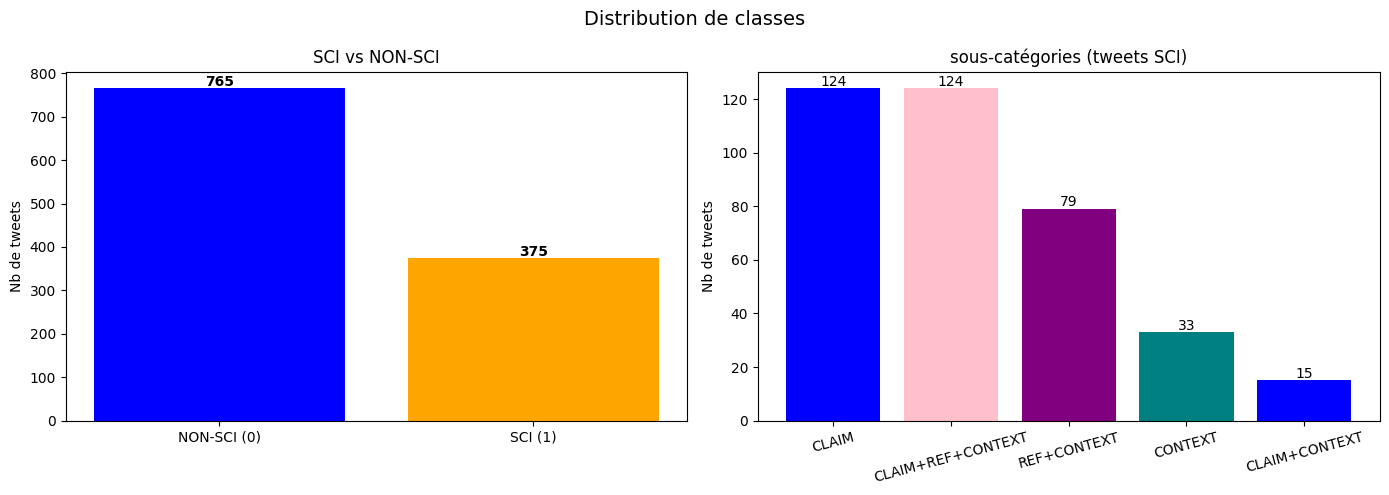

In [22]:
#Distribution des classes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distribution de classes", fontsize=14)

counts_sci = df["science_related"].value_counts()
axes[0].bar(
    ["NON-SCI (0)", "SCI (1)"],
    [counts_sci.get(0, 0), counts_sci.get(1, 0)],
    color=["blue", "orange"]
)
axes[0].set_title("SCI vs NON-SCI")
axes[0].set_ylabel("Nb de tweets")
for i, v in enumerate([counts_sci.get(0, 0), counts_sci.get(1, 0)]):
    axes[0].text(i, v + 5, str(v), ha="center", fontweight="bold")

# pour les sous-catégories
df_sci = df[df["science_related"] == 1].copy()

def get_label(row):
    labels = []
    if row["scientific_claim"] == 1:
        labels.append("CLAIM")
    if row["scientific_reference"] == 1:
        labels.append("REF")
    if row["scientific_context"] == 1:
        labels.append("CONTEXT")
    return "+".join(labels) if labels else "UNKNOWN"

df_sci["sublabel"] = df_sci.apply(get_label, axis=1)
sublabel_counts = df_sci["sublabel"].value_counts()

axes[1].bar(sublabel_counts.index, sublabel_counts.values, color=["blue", "pink","purple","teal"])
axes[1].set_title("sous-catégories (tweets SCI)")
axes[1].set_ylabel("Nb de tweets")
axes[1].tick_params(axis="x", rotation=15)
for i, v in enumerate(sublabel_counts.values):
    axes[1].text(i, v + 1, str(v), ha="center")

plt.tight_layout()
plt.show()

On observe un désequilibre dans la répartition, cela demande un modèle plus compliquée vu qu'il serait appris sur 2:1 data

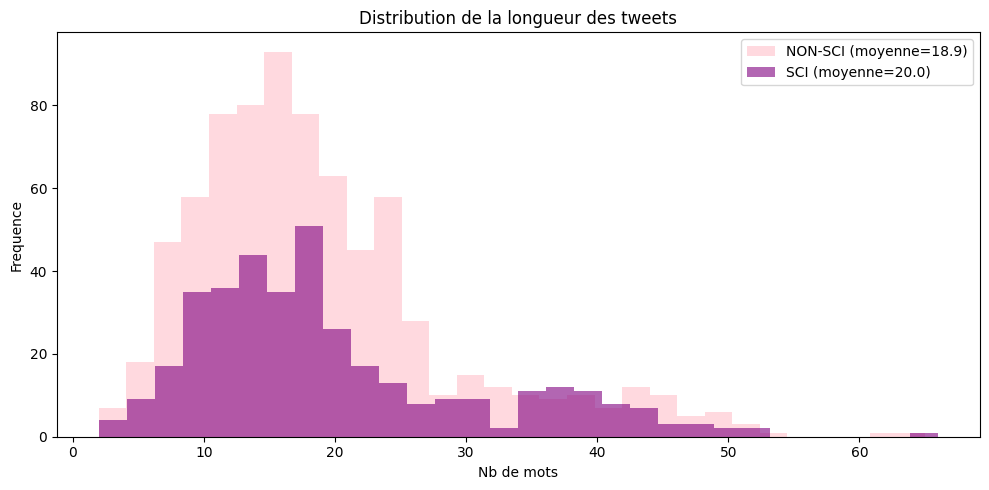

In [23]:
###################################################
# un petit test pour voir si la longueur d'un tweet dit qlq chose sur ça catégorie (sci ou ono-sci)

df["tweet_length"] = df["text"].apply(lambda x: len(str(x).split()))

fig, ax = plt.subplots(figsize=(10, 5))
for label, color, name in [(0, "pink", "NON-SCI"), (1, "purple", "SCI")]:
    subset = df[df["science_related"] == label]["tweet_length"]
    ax.hist(subset, bins=30, alpha=0.6, color=color, label=f"{name} (moyenne={subset.mean():.1f})")

ax.set_title("Distribution de la longueur des tweets")
ax.set_xlabel("Nb de mots")
ax.set_ylabel("Frequence")
ax.legend()
plt.tight_layout()
plt.show()


Les 2 graphes sont presque identique signifiant que cette mesure de longueur de tweets n'est pas utile.

Variance expliquée par les 3 composantes PCA : 17.5%
  PC1: 7.5%  PC2: 5.8%  PC3: 4.2%


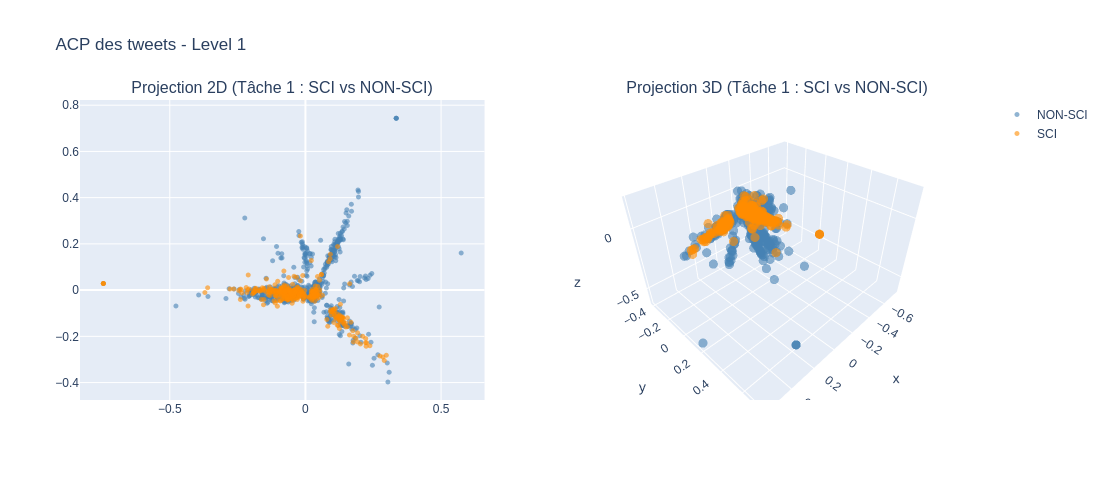

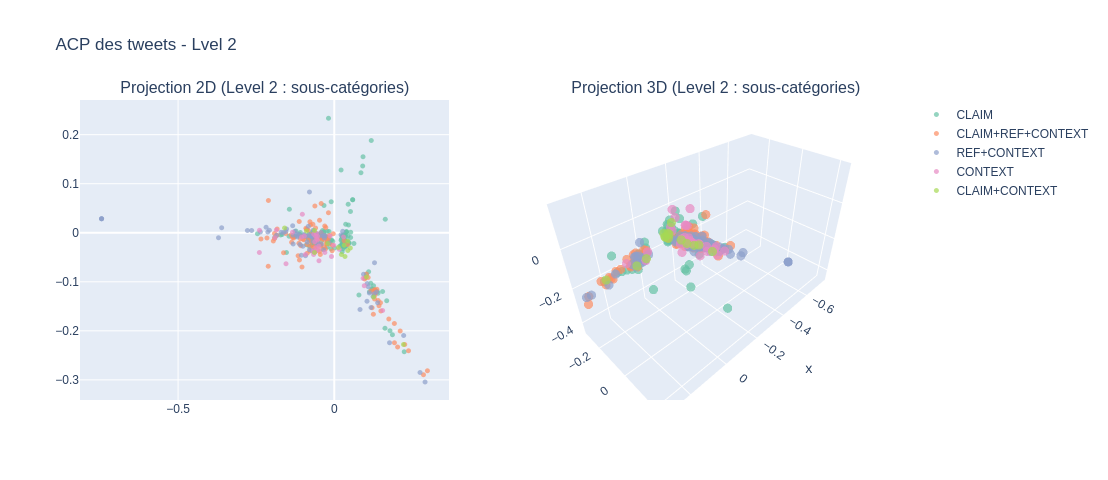

In [24]:
#ACP ###############################################

vectorizer = TfidfVectorizer(
    max_features=2000,
    stop_words="english"
)
X_tfidf = vectorizer.fit_transform(df["text"])

svd = TruncatedSVD(n_components=50, random_state=42)
X_svd = svd.fit_transform(X_tfidf)

pca = PCA(n_components=3, random_state=42)
X_pca_3d = pca.fit_transform(X_svd)

print(f"Variance expliquée par les 3 composantes PCA : "
      f"{pca.explained_variance_ratio_.sum()*100:.1f}%")
print(f"  PC1: {pca.explained_variance_ratio_[0]*100:.1f}%  "
      f"PC2: {pca.explained_variance_ratio_[1]*100:.1f}%  "
      f"PC3: {pca.explained_variance_ratio_[2]*100:.1f}%")

color_task1 = df["science_related"].map({0: "NON-SCI", 1: "SCI"})

df_pca = pd.DataFrame({
    "PC1": X_pca_3d[:, 0],
    "PC2": X_pca_3d[:, 1],
    "PC3": X_pca_3d[:, 2],
    "Tache1": color_task1,
})

fig = make_subplots(
    rows=1, cols=2,
    specs=[[{"type": "xy"}, {"type": "scene"}]],
    subplot_titles=("Projection 2D (Tâche 1 : SCI vs NON-SCI)",
                    "Projection 3D (Tâche 1 : SCI vs NON-SCI)")
)

color_map = {"NON-SCI": "steelblue", "SCI": "darkorange"}

for label in ["NON-SCI", "SCI"]:
    mask = df_pca["Tache1"] == label
    fig.add_trace(
        go.Scatter(
            x=df_pca.loc[mask, "PC1"],
            y=df_pca.loc[mask, "PC2"],
            mode="markers",
            name=label,
            marker=dict(color=color_map[label], size=5, opacity=0.6)
        ),
        row=1, col=1
    )
    fig.add_trace(
        go.Scatter3d(
            x=df_pca.loc[mask, "PC1"],
            y=df_pca.loc[mask, "PC2"],
            z=df_pca.loc[mask, "PC3"],
            mode="markers",
            name=label,
            showlegend=False,
            marker=dict(color=color_map[label], size=3, opacity=0.6)
        ),
        row=1, col=2
    )

fig.update_layout(
    title="ACP des tweets - Level 1",
    width=1000, height=480
)
fig.show()


mask_sci = df["science_related"] == 1
df_pca_sci = df_pca[mask_sci].copy()
df_pca_sci["sublabel"] = df_sci["sublabel"].values

fig2 = make_subplots(
    rows=1, cols=2,
    specs=[[{"type": "xy"}, {"type": "scene"}]],
    subplot_titles=("Projection 2D (Level 2 : sous-catégories)",
                    "Projection 3D (Level 2 : sous-catégories)")
)

colors_sub = px.colors.qualitative.Set2
unique_labels = df_pca_sci["sublabel"].unique()

for i, label in enumerate(unique_labels):
    mask = df_pca_sci["sublabel"] == label
    color = colors_sub[i % len(colors_sub)]
    fig2.add_trace(
        go.Scatter(
            x=df_pca_sci.loc[mask, "PC1"],
            y=df_pca_sci.loc[mask, "PC2"],
            mode="markers",
            name=label,
            marker=dict(color=color, size=5, opacity=0.7)
        ),
        row=1, col=1
    )
    fig2.add_trace(
        go.Scatter3d(
            x=df_pca_sci.loc[mask, "PC1"],
            y=df_pca_sci.loc[mask, "PC2"],
            z=df_pca_sci.loc[mask, "PC3"],
            mode="markers",
            name=label,
            showlegend=False,
            marker=dict(color=color, size=3, opacity=0.7)
        ),
        row=1, col=2
    )

fig2.update_layout(
    title="ACP des tweets - Lvel 2",
    width=1000, height=480
)
fig2.show()


Les classes sont très mélangées, on observe aucune séparation linéaire clair.

# 4. Ingenierie de Données

In [52]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()
def get_wordnet(tag):
    if tag.startswith('J'): return wordnet.ADJ
    if tag.startswith('V'): return wordnet.VERB
    if tag.startswith('N'): return wordnet.NOUN
    if tag.startswith('R'): return wordnet.ADV
    return wordnet.NOUN

contractions_map = {
    "don't": "do not",
    "doesn't": "does not",
    "can't": "cannot",
    "won't": "will not",
    "i'm": "i am",
    "it's": "it is",
    "you're": "you are",
    "they're": "they are",
    "we're": "we are",
    "that's": "that is",
}
def expand_contractions(text):
    # Normalisation simple des apostrophes typographiques
    text = text.replace("’", "'")
    tokens = text.split()
    expanded = []
    for t in tokens:
        key = t.lower()
        if key in contractions_map:
            expanded.extend(contractions_map[key].split())
        else:
            expanded.append(t)
    return " ".join(expanded)
    
    
def preprocess(text):
    text = expand_contractions(text)
    text = str(text).lower()

    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'\bhttp\w+\b', '', text)
    text = re.sub(r'@\w+','',text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = emoji.demojize(text, delimiters=(" ", " "))
    text = text.replace("_", " ")
    text = re.sub(r'[^\w\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    tags = nltk.pos_tag(tokens)
    tokens = [
        lemmatizer.lemmatize(word, get_wordnet(tag))
        for word, tag in tags
    ]
    
    return " ".join(tokens)


In [53]:
df["text_clean"] = df["text"].apply(preprocess)

for i in range(3):
    print("BEFORE:", df["text"].iloc[i])
    print("AFTER: ", df["text_clean"].iloc[i])
    print()

BEFORE: Knees are a bit sore. i guess that's a sign that my recent treadmilling is working
AFTER:  knee bite sore guess sign recent treadmilling work

BEFORE: McDonald's breakfast stop then the gym 🏀💪
AFTER:  mcdonalds breakfast stop gym basketball flex biceps

BEFORE: Can any Gynecologist with Cancer Experience explain the dangers of Transvaginal Douching with Fluoride or other toxins such as Dioxin? #PDX
AFTER:  gynecologist cancer experience explain danger transvaginal douche fluoride toxin dioxin pdx



In [54]:
#wth are these tweets actually 😭

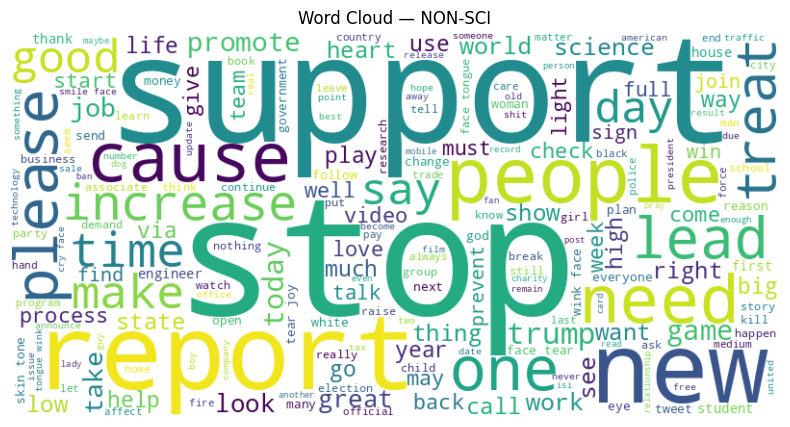

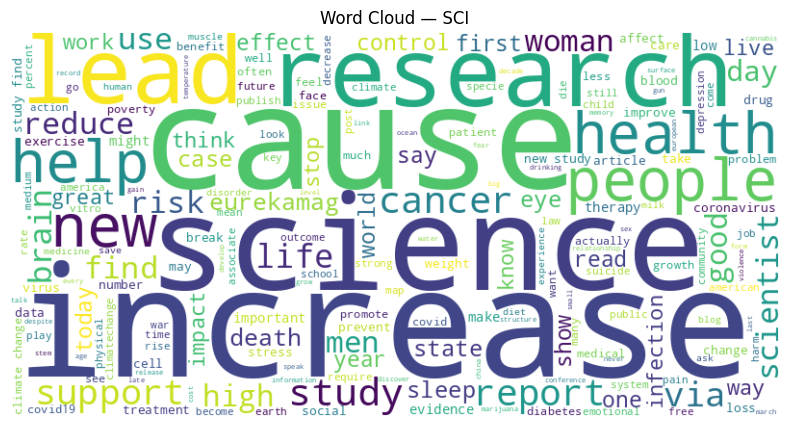

In [55]:
for label, name in [(0, "NON-SCI"), (1, "SCI")]:
    texts = " ".join(df[df["science_related"] == label]["text_clean"])
    wc = WordCloud(width=800, height=400, background_color="white")
    wc.generate(texts)
    plt.figure(figsize=(12, 5))
    plt.title(f"Word Cloud — {name}")
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.show()

# 5. Vectorisation des Documents via TfidfVectorizer

Le but de la vectorisation est de transformer chaque document en vecteur afin d’obtenir une matrice utilisable
comme variables prédictives.
Note : Une limite importante de ces approches est l’absence d’information sur l’ordre des mots. Les n-grammes
peuvent réduire ce problème, mais dès que la structure d’une phrase devient importante, il faut se tourner
vers d’autres méthodes, comme celles utilisées dans les modèles plus récents (LSTM, Transformers, etc.).

In [56]:
# Initialisation du vecteur TF-IDF
vectorizer = TfidfVectorizer(
    stop_words='english', # Stopwords anglais
    max_features=2000, # Limiter à 2000 tokens au total
    token_pattern=r'[a-zA-Z]{2,}' #added because i had numbers 
)
# fit + transform
X = vectorizer.fit_transform(df['text_clean'])
# Affichage sous forme de DataFrame
df_tfidf = pd.DataFrame(
data=X.toarray(),
columns=vectorizer.get_feature_names_out()
)
print(df_tfidf)

      aap  ability  able  abortion  abuse  academic  academy  accept  accord  \
0     0.0      0.0   0.0       0.0    0.0       0.0      0.0     0.0     0.0   
1     0.0      0.0   0.0       0.0    0.0       0.0      0.0     0.0     0.0   
2     0.0      0.0   0.0       0.0    0.0       0.0      0.0     0.0     0.0   
3     0.0      0.0   0.0       0.0    0.0       0.0      0.0     0.0     0.0   
4     0.0      0.0   0.0       0.0    0.0       0.0      0.0     0.0     0.0   
...   ...      ...   ...       ...    ...       ...      ...     ...     ...   
1135  0.0      0.0   0.0       0.0    0.0       0.0      0.0     0.0     0.0   
1136  0.0      0.0   0.0       0.0    0.0       0.0      0.0     0.0     0.0   
1137  0.0      0.0   0.0       0.0    0.0       0.0      0.0     0.0     0.0   
1138  0.0      0.0   0.0       0.0    0.0       0.0      0.0     0.0     0.0   
1139  0.0      0.0   0.0       0.0    0.0       0.0      0.0     0.0     0.0   

      account  ...  year  yes  yesterda

In [57]:
#hmmm a few weird words there but we'll keep it

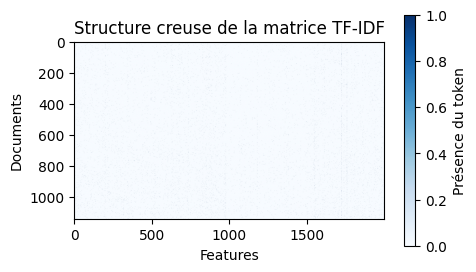

In [58]:
M_tfidf = X.toarray()
plt.figure(figsize=(5, 3))
plt.imshow(M_tfidf > 0, cmap="Blues") # bleu = valeur non nulle, gris = zéro
plt.title("Structure creuse de la matrice TF-IDF")
plt.xlabel("Features")
plt.ylabel("Documents")
plt.colorbar(label="Présence du token")
plt.show()

In [59]:
#well that looks useless, but it makes sense as tweets are short and for 2000 features most of it would be zero

In [61]:
features = vectorizer.get_feature_names_out()
print(f"features: {features[:20]} \n")

means = X.mean(axis=0).A1  #A1 flattens the matrix
topT = means.argsort()[::-1][:20]
print("top 20 tokens by tf-idf mean score")
for i in topT:
    print(f"  {features[i]:<20} {means[i]:.4f}")

features: ['aap' 'ability' 'able' 'abortion' 'abuse' 'academic' 'academy' 'accept'
 'accord' 'account' 'accuse' 'achievement' 'act' 'action' 'activist'
 'activity' 'actually' 'ad' 'add' 'additional'] 

top 20 tokens by tf-idf mean score
  stop                 0.0355
  support              0.0273
  report               0.0176
  cause                0.0151
  people               0.0144
  new                  0.0129
  science              0.0114
  lead                 0.0111
  increase             0.0111
  face                 0.0110
  good                 0.0097
  study                0.0095
  need                 0.0091
  life                 0.0081
  research             0.0081
  like                 0.0080
  help                 0.0076
  change               0.0073
  day                  0.0073
  world                0.0072


# 6. Classification

In [77]:
pipeline = Pipeline([
    ("vectorizer", TfidfVectorizer(
        ngram_range=(1, 2),
        preprocessor= preprocess, 
        #stop_words='english',
        max_features=2000,
        token_pattern=r'\b(?!http)\w{3,}\b',
        min_df=3,
        max_df=0.8
    )),
    ("clf", SVC(kernel="linear")) #for now we are sticking t SVM but we'll compare with other classifiers
])

X = df["text"]
y = df["science_related"]

In [86]:
validation_size = 0.3 # 30 % du jeu de données pour le test
seed = 30
X_train, X_test, y_train, y_test = train_test_split(
X, y,
test_size=validation_size,
random_state=seed
)
print ("Format du jeu d'apprentissage : ",X_train.shape)
print ("Format du jeu de test :", X_test.shape)

Format du jeu d'apprentissage :  (798,)
Format du jeu de test : (342,)


In [87]:
pipeline.fit(X_train, y_train)
print("Accuracy:", pipeline.score(X_test, y_test))
y_pred = pipeline.predict(X_test)
conf = confusion_matrix(y_test, y_pred)
print("\nMatrice de confusion\n", conf)
print("\nClassification report\n",
classification_report(y_test, y_pred))

Accuracy: 0.7719298245614035

Matrice de confusion
 [[189  44]
 [ 34  75]]

Classification report
               precision    recall  f1-score   support

           0       0.85      0.81      0.83       233
           1       0.63      0.69      0.66       109

    accuracy                           0.77       342
   macro avg       0.74      0.75      0.74       342
weighted avg       0.78      0.77      0.77       342



### Remarques : 
tandis que l'accuracy est 80%, l'apprentissage montre un deséquilibre entre les classes, le modele favorise la classe 0 (recall=0.91)
la matrice de confusion le montre aussi avec 50 SCI "misclassified as NON-SCI" contre 20 NON-SCI misclassified as SCI 
on peut résumé cela on disons que notre modèle classifie bien les tweets comme NON-SCI mais inutile pour les classifié comme SCI et cela est un résultat du deséquilibre de répartition des classes (765 pour classe 0 et 375 pour classe 1) 

In [85]:
pipeline.set_params(clf=SVC(kernel="linear", class_weight="balanced"))

Pipeline(steps=[('vectorizer',
                 TfidfVectorizer(max_df=0.8, max_features=2000, min_df=3,
                                 ngram_range=(1, 2),
                                 preprocessor=<function preprocess at 0x77752ea44a60>,
                                 token_pattern='\\b(?!http)\\w{3,}\\b')),
                ('clf', SVC(class_weight='balanced', kernel='linear'))])

In [88]:
kfold = KFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_val_score(pipeline, X, y, cv=kfold, scoring="f1")
print(f"F1 moyen: {scores.mean():.3f} ± {scores.std():.3f}")

F1 moyen: 0.678 ± 0.056


## Comparaison avec d'autres classifieurs

In [93]:
kfold = KFold(n_splits=10, shuffle=True, random_state=42)
X_clean = df["text_clean"]

models = [
    ("SVM linear (baseline)",   SVC(kernel="linear")),
    ("SVM linear (balanced)",   SVC(kernel="linear", class_weight="balanced")),
    ("SVM RBF (balanced)",      SVC(kernel="rbf", class_weight="balanced")),
    ("Logistic Regression",     LogisticRegression(class_weight="balanced", max_iter=1000)),
    ("Random Forest",           RandomForestClassifier(class_weight="balanced", random_state=42)),
    ("Decision Tree",           DecisionTreeClassifier(class_weight="balanced", random_state=42)),
    ("Naive Bayes",             MultinomialNB()),
    ("KNN",                     KNeighborsClassifier()),
]

print(f"{'Model':<30} {'F1 mean':>10} {'F1 std':>10} {'Acc mean':>10}")
print("-" * 64)

results = []
for name, clf in models:
    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(
            ngram_range=(1, 2),
            max_features=3000,
            token_pattern=r'\b(?!http)\w{3,}\b',
            min_df=3,
            max_df=0.8
        )),
        ("clf", clf)
    ])
    f1 = cross_val_score(pipe, X, y, cv=kfold, scoring="f1")
    acc = cross_val_score(pipe, X, y, cv=kfold, scoring="accuracy")
    results.append((name, f1.mean(), f1.std(), acc.mean()))
    print(f"{name:<30} {f1.mean():>10.3f} {f1.std():>10.3f} {acc.mean():>10.3f}")

Model                             F1 mean     F1 std   Acc mean
----------------------------------------------------------------
SVM linear (baseline)               0.653      0.081      0.801
SVM linear (balanced)               0.684      0.062      0.783
SVM RBF (balanced)                  0.672      0.077      0.799
Logistic Regression                 0.699      0.064      0.796
Random Forest                       0.622      0.070      0.787
Decision Tree                       0.598      0.080      0.738
Naive Bayes                         0.514      0.084      0.776
KNN                                 0.484      0.078      0.702


In [95]:
experiments = [
    ("unigrams",     df["text"],       TfidfVectorizer(max_features=2000, min_df=3, max_df=0.8)),
    ("bigrams",      df["text"],       TfidfVectorizer(ngram_range=(1,2), max_features=3000, min_df=3, max_df=0.8)),
    ("text_clean",   df["text_clean"], TfidfVectorizer(max_features=2000, min_df=3, max_df=0.8)),
    ("5000 features",df["text"],       TfidfVectorizer(max_features=5000, min_df=3, max_df=0.8)),
    ("bigrams + 5000 features",df["text"],       TfidfVectorizer(max_features=5000, min_df=3, max_df=0.8)),
    ("text_clean + bigrams",   df["text_clean"], TfidfVectorizer(ngram_range=(1,2), max_features=2000, min_df=3, max_df=0.8)),
    ("text_clean + 5000 f",   df["text_clean"], TfidfVectorizer(ngram_range=(1,2), max_features=5000, min_df=3, max_df=0.8)),
    ("text_clean + bigrams + 5000f",   df["text_clean"], TfidfVectorizer(ngram_range=(1,2), max_features=5000, min_df=3, max_df=0.8)),
]

clf = LogisticRegression(class_weight="balanced", max_iter=1000)

print(f"{'Experiment':<35} {'F1 mean':>10} {'F1 std':>10}")
print("-" * 55)
for name, X_exp, vectorizer in experiments:
    pipe = Pipeline([("tfidf", vectorizer), ("clf", clf)])
    f1 = cross_val_score(pipe, X_exp, y, cv=kfold, scoring="f1")
    print(f"{name:<35} {f1.mean():>10.3f} {f1.std():>10.3f}")

Experiment                             F1 mean     F1 std
-------------------------------------------------------
unigrams                                 0.707      0.066
bigrams                                  0.717      0.066
text_clean                               0.691      0.070
5000 features                            0.707      0.066
bigrams + 5000 features                  0.707      0.066
text_clean + bigrams                     0.691      0.070
text_clean + 5000 f                      0.691      0.070
text_clean + bigrams + 5000f             0.691      0.070


In [101]:
def objective(trial):
    C = trial.suggest_float("C", 0.01, 100, log=True)
    max_features = trial.suggest_int("max_features", 1000, 5000, step=500)
    min_df = trial.suggest_int("min_df", 1, 5)
    
    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(
            ngram_range=(1, 2),
            max_features=max_features,
            min_df=min_df,
            max_df=0.8
        )),
        ("clf", LogisticRegression(
            C=C,
            class_weight="balanced",
            max_iter=1000
        ))
    ])
    scores = cross_val_score(pipe, df["text"], y, cv=5, scoring="f1")
    return scores.mean()

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print("Meilleur score Optuna :", study.best_value, "\n")
print("Meilleurs hyperparamètres :")
print(study.best_params)

Meilleur score Optuna : 0.7074980527779413 

Meilleurs hyperparamètres :
{'C': 3.2393644392472085, 'max_features': 4000, 'min_df': 4}


In [103]:
best_params = study.best_params

pipeline_final = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=best_params["max_features"],
        min_df=best_params["min_df"],
        max_df=0.8,
        stop_words="english",
        preprocessor=preprocess
    )),
    ("clf", LogisticRegression(
        C=best_params["C"],
        class_weight="balanced",
        max_iter=1000
    ))
])